In [1]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import ssl
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import numpy as np
import pandas as pd
from PIL import Image

## train

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
data_dir = "images_3"
train_dir = os.path.join(data_dir, "train_images")
val_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [10]:
ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False  # Freeze layers

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


In [12]:
num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

Epoch 1/20 | Train Loss: 0.9370, Acc: 0.6581 | Val Loss: 0.7534, Acc: 0.7672
Epoch 2/20 | Train Loss: 0.8132, Acc: 0.7350 | Val Loss: 0.6579, Acc: 0.8122
Epoch 3/20 | Train Loss: 0.7949, Acc: 0.7433 | Val Loss: 0.6484, Acc: 0.8092
Epoch 4/20 | Train Loss: 0.7812, Acc: 0.7506 | Val Loss: 0.6297, Acc: 0.8212
Epoch 5/20 | Train Loss: 0.7721, Acc: 0.7546 | Val Loss: 0.6127, Acc: 0.8282
Epoch 6/20 | Train Loss: 0.7596, Acc: 0.7625 | Val Loss: 0.6496, Acc: 0.8102
Epoch 7/20 | Train Loss: 0.7633, Acc: 0.7645 | Val Loss: 0.6065, Acc: 0.8372
Epoch 8/20 | Train Loss: 0.7605, Acc: 0.7649 | Val Loss: 0.6055, Acc: 0.8292
Epoch 9/20 | Train Loss: 0.7601, Acc: 0.7620 | Val Loss: 0.5872, Acc: 0.8382
Epoch 10/20 | Train Loss: 0.7559, Acc: 0.7649 | Val Loss: 0.5960, Acc: 0.8332
Epoch 11/20 | Train Loss: 0.7560, Acc: 0.7665 | Val Loss: 0.6090, Acc: 0.8282
Epoch 12/20 | Train Loss: 0.7561, Acc: 0.7663 | Val Loss: 0.5844, Acc: 0.8521
Epoch 13/20 | Train Loss: 0.7458, Acc: 0.7695 | Val Loss: 0.5961, Acc: 0.

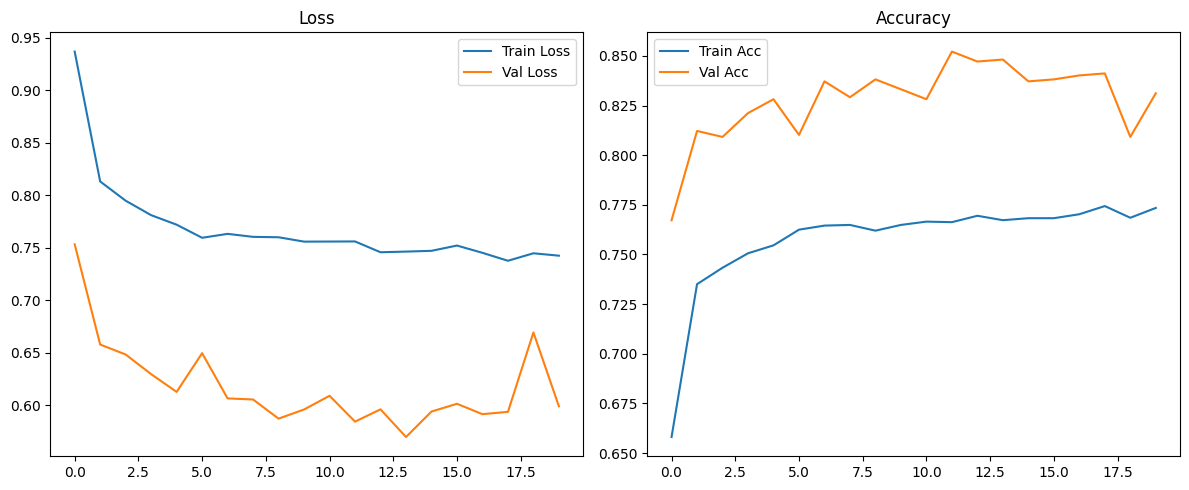

In [13]:
torch.save(model.state_dict(), "resnet18_finetuned.pth")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("loss_accuracy_plot.png")
plt.show()

## đánh giá

In [7]:
data_dir = "data/images_3"
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(test_dataset.classes)
print(num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False  # Freeze layers

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
model.load_state_dict(torch.load("temp/models/resnet18_finetuned.pth",  map_location=device))

label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }

4


In [3]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [4]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 83.22%


In [5]:
class_names = test_dataset.classes
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.88      0.78       250
           1       0.91      0.88      0.89       250
           2       0.90      0.79      0.84       251
           3       0.88      0.78      0.82       244

    accuracy                           0.83       995
   macro avg       0.85      0.83      0.83       995
weighted avg       0.85      0.83      0.83       995



<Figure size 800x600 with 0 Axes>

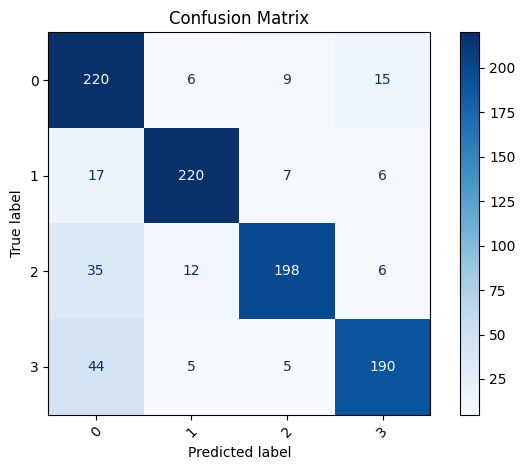

In [6]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

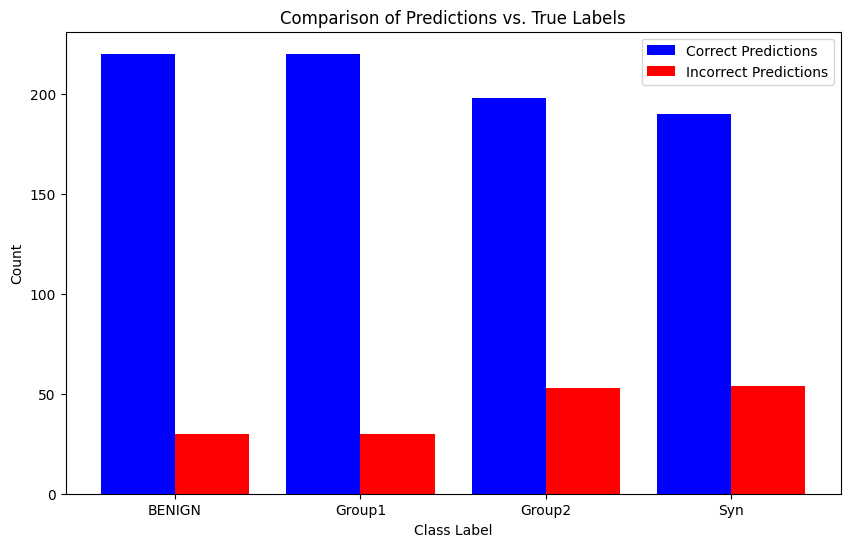

In [8]:
# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": all_labels, "Predicted Label": all_preds})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [9]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [10]:
labels_list = list(label_map.keys())

print(labels_list)
test_data_paths = list(map(lambda x: x, test_dataset.imgs))

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data_paths:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 220, 'Group2': 9, 'Syn': 15, 'Group1': 6}
Label: Group1 {'BENIGN': 17, 'Group1': 220, 'Group2': 7, 'Syn': 6}
Label: Group2 {'BENIGN': 35, 'Group1': 12, 'Group2': 198, 'Syn': 6}
Label: Syn {'BENIGN': 44, 'Syn': 190, 'Group2': 5, 'Group1': 5}
